In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("../../../data/processed/feature_dataset.csv")

In [18]:
# One hot encoding for age and recording location
df = pd.get_dummies(df, columns=["Age"], drop_first=True)

df = pd.get_dummies(df, columns=["recording_location"], drop_first=True)

df = pd.get_dummies(df, columns=["Murmur"], drop_first=True)

df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1
})

In [19]:
# -----------------------------
# Split using your predefined split
# -----------------------------
train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

In [ ]:
# -----------------------------
# Prepare features
# -----------------------------
drop_cols = ["Patient ID", "Outcome", "split", "file", "Campaign", "Additional ID", "Height", "Weight"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Outcome"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["Outcome"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Outcome"]

In [21]:
# Calculate correlation matrix
corr_matrix = X_train.corr()

# Get upper triangle only (avoid duplicate pairs and self-correlation)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated feature pairs
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "Feature 1",
        "level_1": "Feature 2",
        0: "Correlation"
    })
)

# Sort by absolute correlation
high_corr["Abs Correlation"] = high_corr["Correlation"].abs()

high_corr = high_corr.sort_values(
    by="Abs Correlation",
    ascending=False
)

# Show correlations above threshold
threshold = 0.9

print(
    high_corr[
        high_corr["Abs Correlation"] >= threshold
    ]
)

                Feature 1          Feature 2  Correlation  Abs Correlation
220                   rms                std     1.000000         1.000000
1190    spectral_centroid   spectral_rolloff     0.960905         0.960905
1310   spectral_bandwidth        mfcc_2_mean    -0.954890         0.954890
9398          mfcc_12_std     mfcc_d1_12_std     0.949410         0.949410
10046         mfcc_13_std     mfcc_d1_13_std     0.949144         0.949144
8750          mfcc_11_std     mfcc_d1_11_std     0.947708         0.947708
8102          mfcc_10_std     mfcc_d1_10_std     0.943340         0.943340
7454           mfcc_9_std      mfcc_d1_9_std     0.943027         0.943027
1191    spectral_centroid  spectral_flatness     0.937764         0.937764
1297   spectral_bandwidth   spectral_rolloff     0.933680         0.933680
6806           mfcc_8_std      mfcc_d1_8_std     0.925447         0.925447
9400          mfcc_12_std     mfcc_d2_12_std     0.924024         0.924024
7456           mfcc_9_std

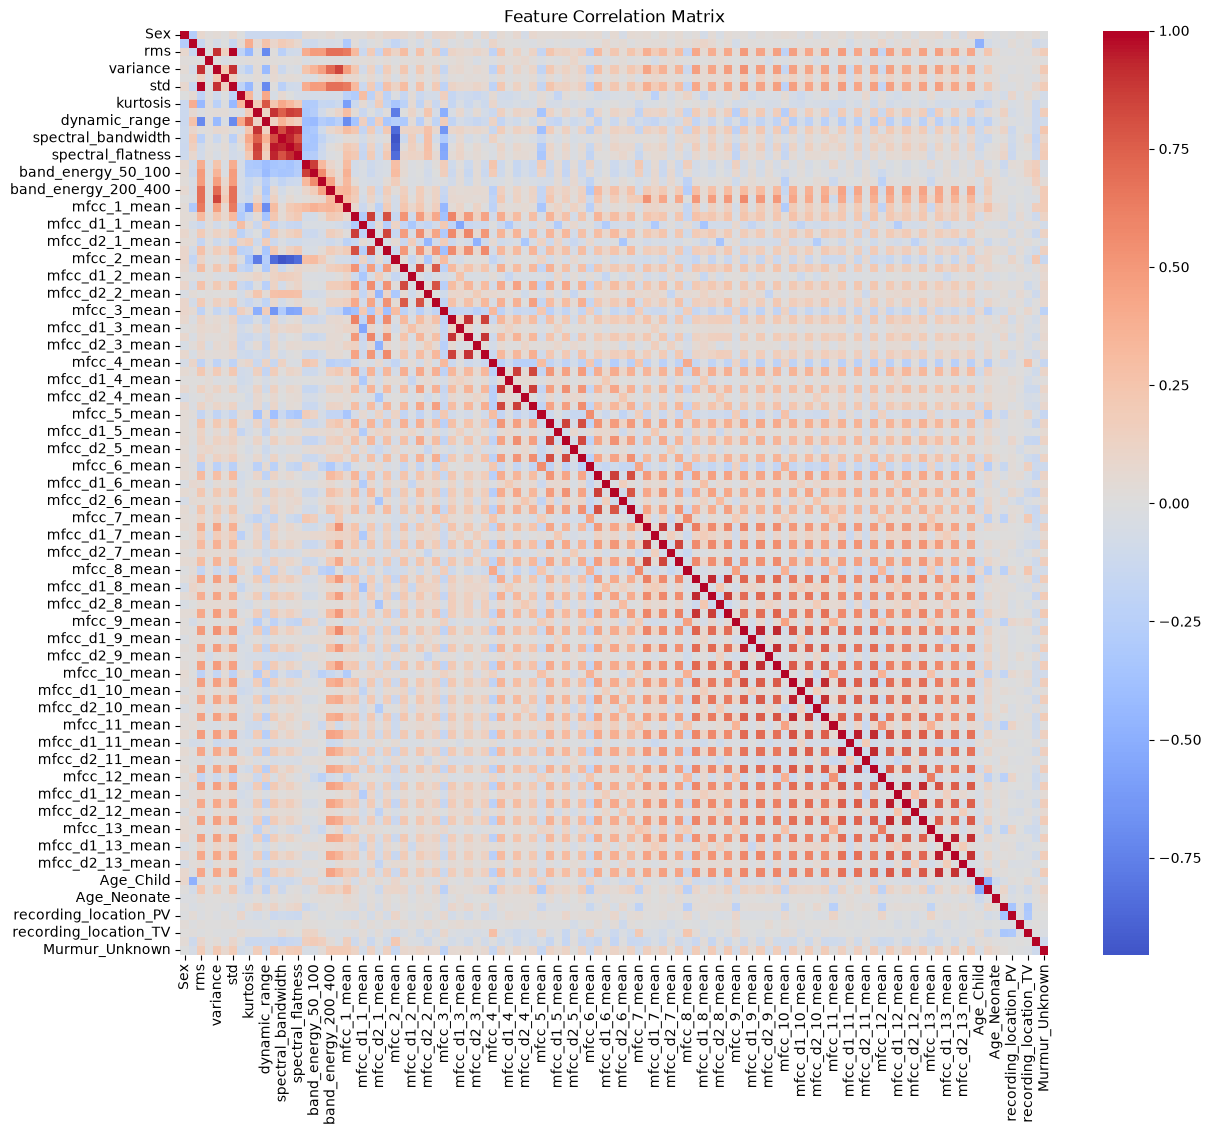

In [ ]:
# Plot heatmap of correlation matrix

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [23]:
# -----------------------------
# Scaling (IMPORTANT for linear models)
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [54]:
# Check how many parameters survived regularization
train_df_dropped = train_df.drop(columns=drop_cols)

# -----------------------------
# Models
# -----------------------------
lr_model = LogisticRegression(
    max_iter=4000
)
lr_model.fit(X_train, y_train)

# Lasso (L1 Regularized) Logistic Regression
# Encourages sparsity of of model parameters
lr_l1_model = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.1,
    max_iter=4000
)

lr_l1_model.fit(X_train, y_train)

coef = pd.Series(lr_l1_model.coef_[0], index=train_df_dropped.columns)
print("lr_l1 Selected features:", (coef != 0).sum())
print("lr_l1 Zero coefficients:", (coef == 0).sum())

# Elastic Net Logistic Regression
lr_en_model = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    C=0.1,
    l1_ratio=0.5,   # 50% L1 + 50% L2
    max_iter=4000
)

lr_en_model.fit(X_train, y_train)


coef = pd.Series(
    lr_en_model.coef_[0],
    index=train_df_dropped.columns
)

print("lr_en Selected features:", (coef != 0).sum())
print("lr_en Zero coefficients:", (coef == 0).sum())

c:\Users\malek\Desktop\Malek\Studium\M.Sc Informatik (TUM)\Semester 2\(CaCOM)\CaCOM-HeartWISE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\malek\Desktop\Malek\Studium\M.Sc Informatik (TUM)\Semester 2\(CaCOM)\CaCOM-HeartWISE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


lr_l1 Selected features: 53
lr_l1 Zero coefficients: 54


c:\Users\malek\Desktop\Malek\Studium\M.Sc Informatik (TUM)\Semester 2\(CaCOM)\CaCOM-HeartWISE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


lr_en Selected features: 74
lr_en Zero coefficients: 33


In [58]:
model = lr_en_model

# -----------------------------
# Evaluation
# -----------------------------
print("Test:")
print(classification_report(y_test, model.predict(X_test)))

# -----------------------------
# Evaluation
# -----------------------------
print("Validation:")
print(classification_report(y_val, model.predict(X_val)))

Test:
              precision    recall  f1-score   support

    Abnormal       0.73      0.51      0.60       237
      Normal       0.63      0.81      0.71       237

    accuracy                           0.66       474
   macro avg       0.68      0.66      0.65       474
weighted avg       0.68      0.66      0.65       474

Validation:
              precision    recall  f1-score   support

    Abnormal       0.73      0.51      0.60       219
      Normal       0.66      0.84      0.74       250

    accuracy                           0.68       469
   macro avg       0.69      0.67      0.67       469
weighted avg       0.69      0.68      0.67       469

